Cell 1: the augmentation module (src/augment.py)

Augmentation shows the model a slightly different version of each training image every epoch, so it can't simply memorize them. Every transformation here mimics real variation between X-rays:

Horizontal flip: left and right knees are mirror images.
Rotation (±10°), shift (±5%), zoom (±10%): small differences in how the patient was positioned.
Brightness and contrast (±10%): leftover exposure differences after preprocessing.

Vertical flips are excluded, since an upside-down knee doesn't exist in practice. Empty corners created by rotation or shifting are filled with black, which matches the black edges our preprocessing already produces.

In [1]:
%%writefile /home/afzal/projects/knee-oa-classification/src/augment.py
"""Training-time augmentation. Anatomically sensible: no vertical flips."""
import keras
from keras import layers


def build_augmentation(rotation_deg=10, translate=0.05, zoom=0.10,
                       brightness=0.10, contrast=0.10, seed=42):
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed),
        layers.RandomRotation(rotation_deg / 360, fill_mode="constant", fill_value=0.0, seed=seed),
        layers.RandomTranslation(translate, translate, fill_mode="constant", fill_value=0.0, seed=seed),
        layers.RandomZoom((-zoom, zoom), fill_mode="constant", fill_value=0.0, seed=seed),
        layers.RandomBrightness(brightness, value_range=(0.0, 1.0), seed=seed),
        layers.RandomContrast(contrast, value_range=(0.0, 1.0), seed=seed),
    ], name="augmentation")

Writing /home/afzal/projects/knee-oa-classification/src/augment.py


Cell 2: the reusable training loop (src/train.py)

This packages everything from Phase 4 into one function: compile, train with our callbacks, plot curves, reload the best checkpoint, evaluate and log. verbose=2 prints one clean line per epoch instead of progress bars.

Cell 3: setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.home() / "projects/knee-oa-classification"
sys.path.insert(0, str(PROJECT / "src"))

import keras
import data
import evaluation as ev
import models
import augment
import train

X_train, y_train = data.load_split("train")
X_val, y_val = data.load_split("val")
val_ds = data.make_dataset(X_val, y_val, batch_size=64)
print("train", X_train.shape, "| val", X_val.shape)

I0000 00:00:1791131470.845303    2064 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791131471.133438    2064 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791131472.778584    2064 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


train (5778, 224, 224) | val (826, 224, 224)


I0000 00:00:1791131475.315508    2064 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Cell 4: look at the augmentations before training on them

Never train on augmentations you haven't looked at. This shows one training image (top left) and 11 random augmented versions of it. Every version should still look like a plausible knee X-ray. If anything looks distorted, cropped badly or unnatural, we tune it before spending GPU time.

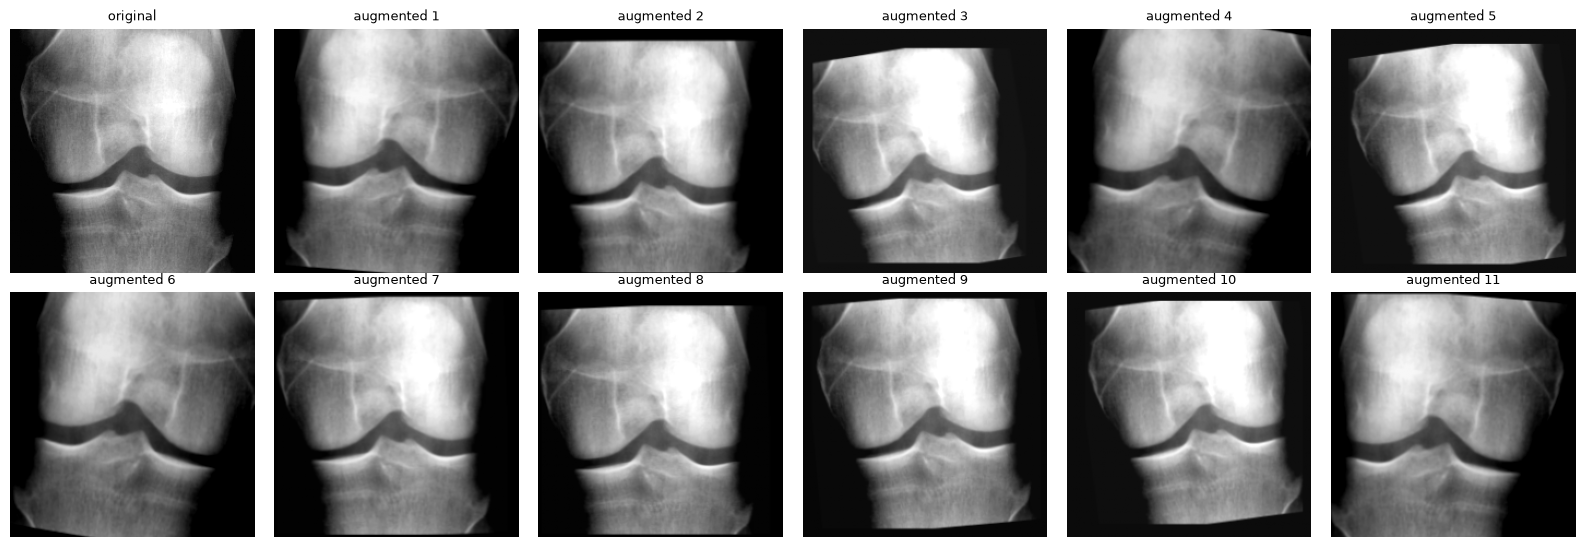

In [4]:
aug = augment.build_augmentation()
img = X_train[0][None, ..., None].astype("float32") / 255.0

fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for i, ax in enumerate(axes.flat):
    out = img if i == 0 else aug(img, training=True)
    ax.imshow(np.asarray(out)[0, ..., 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title("original" if i == 0 else f"augmented {i}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(PROJECT / "reports/augmentation_examples.png", dpi=150)
plt.show()

Cell 5: Experiment 1, the baseline CNN plus augmentation

Same architecture, same seed, same optimizer and callbacks as the baseline. The only change is augmentation. The maximum is 80 epochs instead of 60, because augmented models typically learn more slowly. Early stopping still decides when to stop (the baseline stopped at 37, well under either limit), so this doesn't give the experiment an unfair advantage.

Epoch 1/80


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791029311.262794   15380 service.cc:153] XLA service 0x5c88aff271c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791029311.262832   15380 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791029311.325561   15380 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791029311.708696   15380 cuda_dnn.cc:461] Loaded cuDNN version 92700
I0000 00:00:1791029311.767310   15380 dot_merge

  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 63s - 347ms/step - accuracy: 0.3679 - loss: 1.4565 - val_accuracy: 0.1283 - val_loss: 1.7786 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/80
  val_balanced_accuracy: 0.2858 | val_qwk: 0.0967
181/181 - 21s - 114ms/step - accuracy: 0.4360 - loss: 1.3021 - val_accuracy: 0.2930 - val_loss: 3.4793 - val_balanced_accuracy: 0.2858 - val_qwk: 0.0967 - learning_rate: 0.0010
Epoch 3/80
  val_balanced_accuracy: 0.2681 | val_qwk: 0.0201
181/181 - 21s - 114ms/step - accuracy: 0.4825 - loss: 1.1914 - val_accuracy: 0.0799 - val_loss: 5.7981 - val_balanced_accuracy: 0.2681 - val_qwk: 0.0201 - learning_rate: 0.0010
Epoch 4/80
  val_balanced_accuracy: 0.3132 | val_qwk: 0.0559
181/181 - 21s - 115ms/step - accuracy: 0.4983 - loss: 1.1671 - val_accuracy: 0.1489 - val_loss: 2.0620 - val_balanced_accuracy: 0.3132 - val_qwk: 0.0559 - learning_rate: 0.0010
Epoch 5/80
  val_balanced_accuracy: 0.2433 | val_qwk: 0

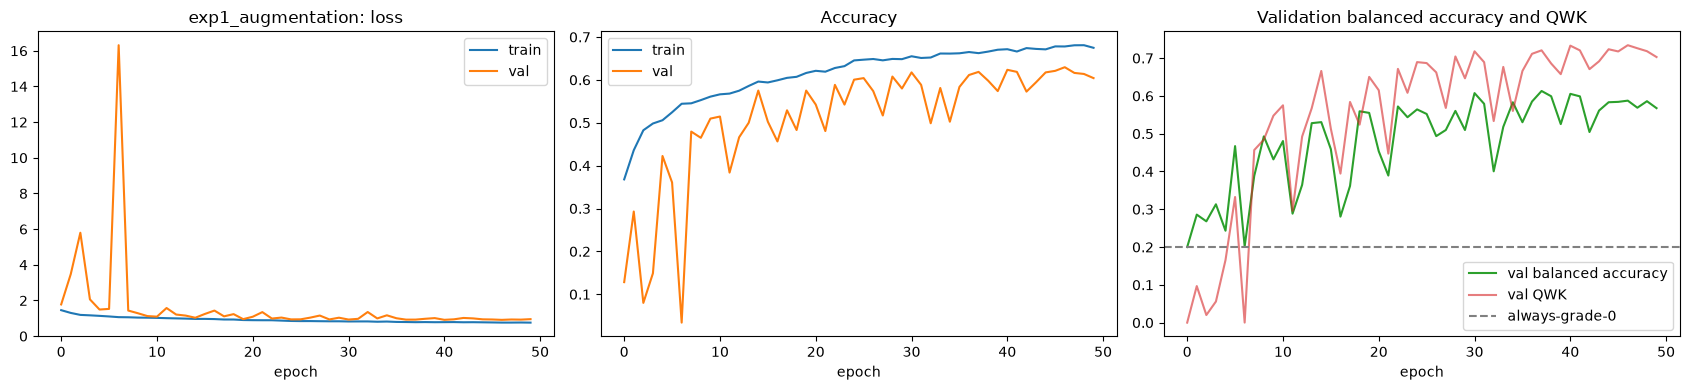

Balanced accuracy: 0.6131 | Accuracy: 0.6186 | QWK: 0.7206 | Macro F1: 0.6010

              precision    recall  f1-score   support

           0      0.664     0.765     0.711       328
           1      0.406     0.085     0.141       153
           2      0.520     0.750     0.614       212
           3      0.783     0.613     0.688       106
           4      0.852     0.852     0.852        27

    accuracy                          0.619       826
   macro avg      0.645     0.613     0.601       826
weighted avg      0.601     0.619     0.582       826



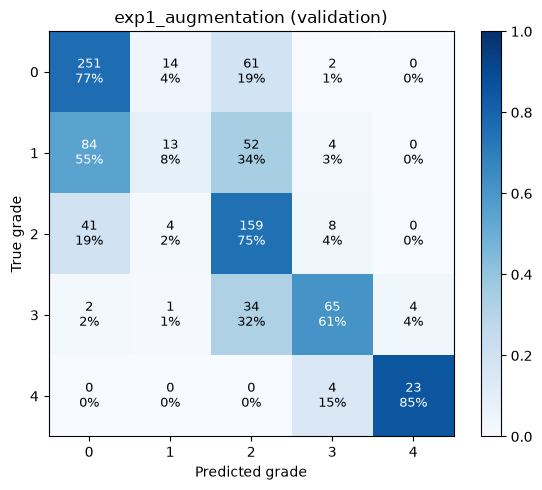

In [5]:
RUN = "exp1_augmentation"
CONFIG = {"model": "baseline_cnn", "filters": [32, 64, 128, 256], "dropout": 0.3,
          "optimizer": "adam", "lr": 1e-3, "batch_size": 32,
          "class_weights": None, "augmentation": "flip+rot10+shift5+zoom10+bc10", "seed": 42}

ev.set_seed(42)
train_ds = data.make_dataset(X_train, y_train, batch_size=32, shuffle=True,
                             augment=augment.build_augmentation())
model = models.build_baseline_cnn()

best, history, m = train.train_and_evaluate(RUN, model, CONFIG, train_ds, val_ds, y_val,
                                            max_epochs=80)

Cell 6: compare against the baseline

In [10]:
cols = ["run", "balanced_accuracy", "accuracy", "qwk", "macro_f1",
        "recall_g0", "recall_g1", "recall_g2", "recall_g3", "recall_g4"]
pd.read_csv(PROJECT / "reports/results.csv")[cols]

,run,balanced_accuracy,accuracy,qwk,macro_f1,recall_g0,recall_g1,recall_g2,recall_g3,recall_g4
0,baseline_always_0,0.2000,0.3971,0.0000,0.1137,1.0000,0.0000,0.0000,0.0000,0.0000
1,baseline_cnn_v1,0.5910,0.5036,0.5563,0.5273,0.3750,0.0784,0.8396,0.7358,0.9259
2,exp1_augmentation,0.6131,0.6186,0.7206,0.6010,0.7652,0.0850,0.7500,0.6132,0.8519
3,exp2_aug_sqrt_class_weights,0.6027,0.6077,0.7228,0.6119,0.8384,0.2418,0.4387,0.7170,0.7778
4,exp3_aug_wider,0.6153,0.6235,0.7132,0.5906,0.7561,0.0523,0.7547,0.7358,0.7778


Experiment 2: augmentation + class weights

Grade 1 is the target. Class weights make mistakes on chosen grades cost more during training. There's also a direct theoretical link: balanced accuracy is the average of per-grade recalls, and inverse-frequency weighting makes training optimize something close to exactly that.

We'll use square-root weights rather than full inverse-frequency ones, because full weighting would give grade 4 about 13 times the weight of grade 0 and risk over-predicting it. Square-root weighting is gentler: it still raises grade 1's weight relative to grades 0 and 2, without distorting the extremes. The weights are scaled so the average weight per image stays 1, keeping the effective learning rate comparable to experiment 1.

Class weights: {0: 0.756, 1: 1.118, 2: 0.929, 3: 1.315, 4: 2.75}
Epoch 1/80


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791030732.379437   15378 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68664__.94
I0000 00:00:1791030755.343083   15381 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68664__.94


  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 33s - 181ms/step - accuracy: 0.3356 - loss: 1.5819 - val_accuracy: 0.1283 - val_loss: 2.1372 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/80
  val_balanced_accuracy: 0.2406 | val_qwk: 0.0602
181/181 - 21s - 114ms/step - accuracy: 0.3814 - loss: 1.4099 - val_accuracy: 0.2821 - val_loss: 1.5320 - val_balanced_accuracy: 0.2406 - val_qwk: 0.0602 - learning_rate: 0.0010
Epoch 3/80
  val_balanced_accuracy: 0.3328 | val_qwk: 0.2855
181/181 - 21s - 114ms/step - accuracy: 0.4271 - loss: 1.2748 - val_accuracy: 0.4346 - val_loss: 1.3205 - val_balanced_accuracy: 0.3328 - val_qwk: 0.2855 - learning_rate: 0.0010
Epoch 4/80
  val_balanced_accuracy: 0.2311 | val_qwk: 0.0444
181/181 - 21s - 114ms/step - accuracy: 0.4685 - loss: 1.2211 - val_accuracy: 0.0714 - val_loss: 5.5732 - val_balanced_accuracy: 0.2311 - val_qwk: 0.0444 - learning_rate: 0.0010
Epoch 5/80
  val_balanced_accuracy: 0.3308 | val_qwk: 0

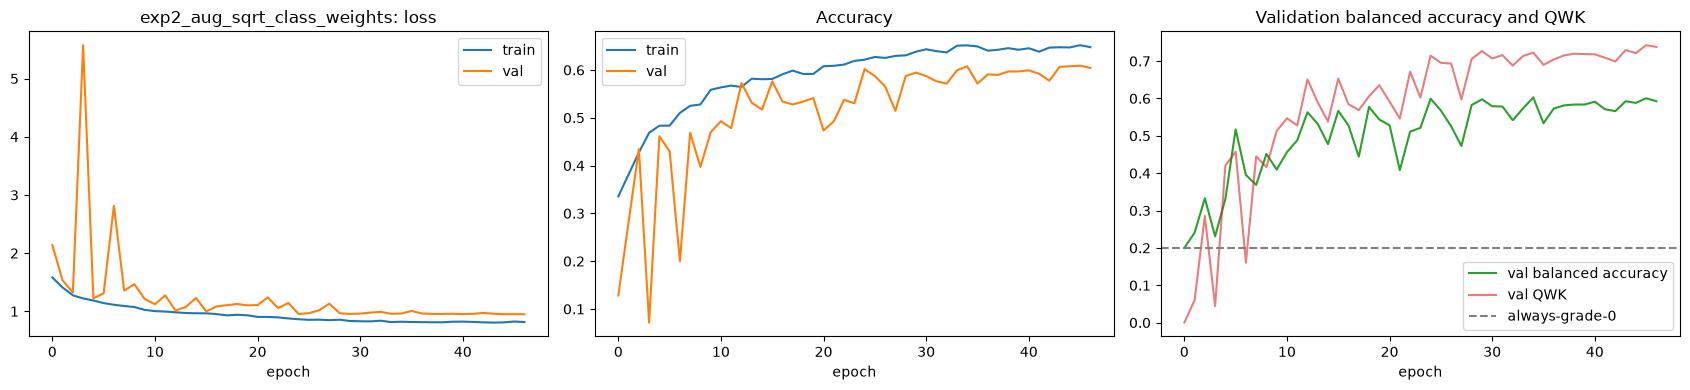

Balanced accuracy: 0.6027 | Accuracy: 0.6077 | QWK: 0.7228 | Macro F1: 0.6119

              precision    recall  f1-score   support

           0      0.640     0.838     0.726       328
           1      0.333     0.242     0.280       153
           2      0.589     0.439     0.503       212
           3      0.738     0.717     0.727       106
           4      0.875     0.778     0.824        27

    accuracy                          0.608       826
   macro avg      0.635     0.603     0.612       826
weighted avg      0.590     0.608     0.589       826



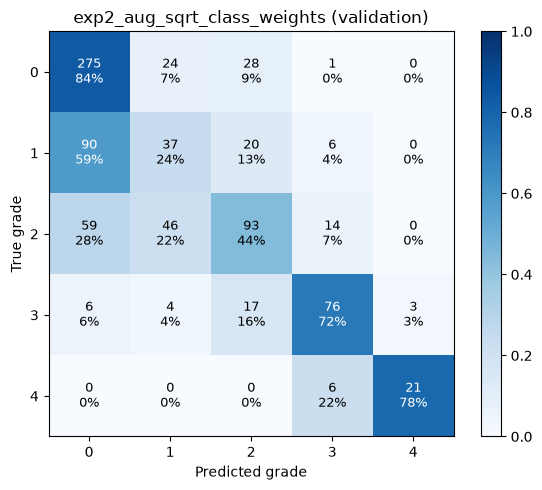

In [7]:
RUN = "exp2_aug_sqrt_class_weights"

counts = np.bincount(y_train)
w = np.sqrt(len(y_train) / (5 * counts))          # square-root of inverse frequency
w = w * len(y_train) / (w * counts).sum()         # scale so the average weight per image is 1
class_weight = {g: float(w[g]) for g in range(5)}
print("Class weights:", {g: round(v, 3) for g, v in class_weight.items()})

CONFIG = {"model": "baseline_cnn", "filters": [32, 64, 128, 256], "dropout": 0.3,
          "optimizer": "adam", "lr": 1e-3, "batch_size": 32,
          "class_weights": "sqrt_inverse_freq", "augmentation": "flip+rot10+shift5+zoom10+bc10",
          "seed": 42}

ev.set_seed(42)
train_ds = data.make_dataset(X_train, y_train, batch_size=32, shuffle=True,
                             augment=augment.build_augmentation())
model = models.build_baseline_cnn()

best, history, m = train.train_and_evaluate(RUN, model, CONFIG, train_ds, val_ds, y_val,
                                            class_weight=class_weight, max_epochs=80)

In [11]:
prior = np.bincount(y_train) / len(y_train)
print("Training-set grade frequencies:", np.round(prior, 3), "\n")

for run in ["exp1_augmentation", "exp3_aug_wider"]:
    mdl = keras.models.load_model(PROJECT / "models" / f"{run}.keras")
    p_val = mdl.predict(val_ds, verbose=0)
    for name, pred in [("argmax", p_val.argmax(axis=1)),
                       ("prior-adjusted", (p_val / prior).argmax(axis=1))]:
        m = ev.compute_metrics(y_val, pred)
        recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
        print(f"{run:20s} {name:15s} bal_acc {m['balanced_accuracy']:.4f} | "
              f"qwk {m['qwk']:.4f} | recalls {recalls}")
        if name == "prior-adjusted":
            ev.log_run(f"{run}+prior_adj", {"base_run": run, "decision": "argmax(p / train_prior)"}, m)
    print()

Training-set grade frequencies: [0.396 0.181 0.262 0.131 0.03 ] 

exp1_augmentation    argmax          bal_acc 0.6131 | qwk 0.7206 | recalls 0.77 / 0.08 / 0.75 / 0.61 / 0.85
exp1_augmentation    prior-adjusted  bal_acc 0.6283 | qwk 0.6932 | recalls 0.33 / 0.61 / 0.59 / 0.69 / 0.93

exp3_aug_wider       argmax          bal_acc 0.6153 | qwk 0.7132 | recalls 0.76 / 0.05 / 0.75 / 0.74 / 0.78
exp3_aug_wider       prior-adjusted  bal_acc 0.6355 | qwk 0.7131 | recalls 0.49 / 0.39 / 0.65 / 0.75 / 0.89



Balanced accuracy: 0.6746 | Accuracy: 0.6694 | QWK: 0.7758 | Macro F1: 0.6536

              precision    recall  f1-score   support

           0      0.700     0.820     0.755      2286
           1      0.459     0.086     0.145      1046
           2      0.571     0.768     0.655      1516
           3      0.849     0.762     0.803       757
           4      0.885     0.936     0.910       173

    accuracy                          0.669      5778
   macro avg      0.693     0.675     0.654      5778
weighted avg      0.647     0.669     0.629      5778



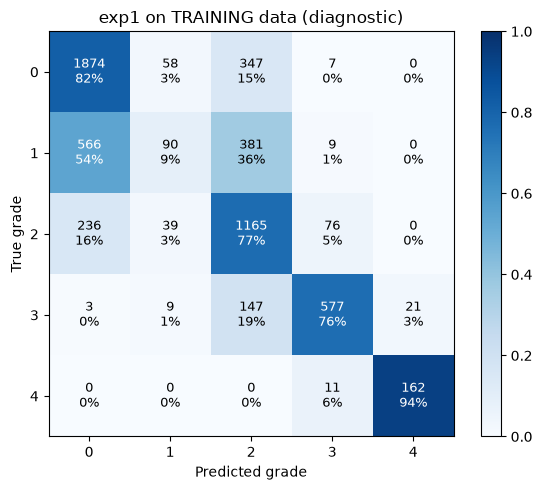

In [12]:
# Diagnostic B: how well does exp1 separate grades on its own TRAINING images?
mdl = keras.models.load_model(PROJECT / "models/exp1_augmentation.keras")
train_eval_ds = data.make_dataset(X_train, y_train, batch_size=64)   # no shuffle, no augmentation
y_pred_train = mdl.predict(train_eval_ds, verbose=0).argmax(axis=1)
_ = ev.evaluate_predictions(y_train, y_pred_train, title="exp1 on TRAINING data (diagnostic)",
                            save_path=PROJECT / "reports/cm_exp1_train_diagnostic.png")

In [13]:
def predict_probs(model, X, flip_tta=False):
    dummy_y = np.zeros(len(X), dtype=np.int64)
    p = model.predict(data.make_dataset(X, dummy_y, batch_size=64), verbose=0)
    if flip_tta:
        X_flipped = X[:, :, ::-1].copy()          # mirror each image left-right
        p = (p + model.predict(data.make_dataset(X_flipped, dummy_y, batch_size=64), verbose=0)) / 2
    return p

m1 = keras.models.load_model(PROJECT / "models/exp1_augmentation.keras")
m3 = keras.models.load_model(PROJECT / "models/exp3_aug_wider.keras")
p1, p1t = predict_probs(m1, X_val), predict_probs(m1, X_val, flip_tta=True)
p3, p3t = predict_probs(m3, X_val), predict_probs(m3, X_val, flip_tta=True)

variants = {"exp1": p1, "exp1 + flip": p1t, "exp3": p3, "exp3 + flip": p3t,
            "ensemble(1,3)": (p1 + p3) / 2, "ensemble(1,3) + flip": (p1t + p3t) / 2}

for name, p in variants.items():
    for rule, pred in [("argmax", p.argmax(axis=1)), ("prior-adj", (p / prior).argmax(axis=1))]:
        m = ev.compute_metrics(y_val, pred)
        recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
        print(f"{name:22s} {rule:9s} bal_acc {m['balanced_accuracy']:.4f} | "
              f"qwk {m['qwk']:.4f} | recalls {recalls}")
    print()

m_best = ev.compute_metrics(y_val, (((p1t + p3t) / 2) / prior).argmax(axis=1))
ev.log_run("ensemble_exp1_exp3+flip+prior_adj",
           {"members": ["exp1_augmentation", "exp3_aug_wider"], "tta": "hflip",
            "decision": "argmax(p / train_prior)"}, m_best)

exp1                   argmax    bal_acc 0.6131 | qwk 0.7206 | recalls 0.77 / 0.08 / 0.75 / 0.61 / 0.85
exp1                   prior-adj bal_acc 0.6283 | qwk 0.6932 | recalls 0.33 / 0.61 / 0.59 / 0.69 / 0.93

exp1 + flip            argmax    bal_acc 0.6059 | qwk 0.7258 | recalls 0.77 / 0.06 / 0.74 / 0.60 / 0.85
exp1 + flip            prior-adj bal_acc 0.6282 | qwk 0.7071 | recalls 0.32 / 0.59 / 0.58 / 0.72 / 0.93

exp3                   argmax    bal_acc 0.6153 | qwk 0.7132 | recalls 0.76 / 0.05 / 0.75 / 0.74 / 0.78
exp3                   prior-adj bal_acc 0.6355 | qwk 0.7131 | recalls 0.49 / 0.39 / 0.65 / 0.75 / 0.89

exp3 + flip            argmax    bal_acc 0.6153 | qwk 0.7192 | recalls 0.76 / 0.05 / 0.75 / 0.74 / 0.78
exp3 + flip            prior-adj bal_acc 0.6494 | qwk 0.7162 | recalls 0.48 / 0.41 / 0.66 / 0.76 / 0.93

ensemble(1,3)          argmax    bal_acc 0.6300 | qwk 0.7256 | recalls 0.77 / 0.05 / 0.75 / 0.73 / 0.85
ensemble(1,3)          prior-adj bal_acc 0.6467 | qwk 0.7115

{'timestamp': '2026-10-03T13:57:25',
 'run': 'ensemble_exp1_exp3+flip+prior_adj',
 'split': 'val',
 'balanced_accuracy': 0.644,
 'accuracy': 0.5448,
 'qwk': 0.7103,
 'macro_f1': 0.6007,
 'recall_g0': 0.4024,
 'recall_g1': 0.5098,
 'recall_g2': 0.6462,
 'recall_g3': 0.7358,
 'recall_g4': 0.9259,
 'config': '{"members": ["exp1_augmentation", "exp3_aug_wider"], "tta": "hflip", "decision": "argmax(p / train_prior)"}'}

In [2]:
%%writefile /home/afzal/projects/knee-oa-classification/src/train.py
"""Reusable training + evaluation loop so every experiment runs identically.

Supports softmax models (default) and other output formats via `loss` and `decode_fn`.
"""
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score

import evaluation as ev

PROJECT = Path.home() / "projects/knee-oa-classification"
MODELS = PROJECT / "models"
REPORTS = PROJECT / "reports"


def argmax_decode(p):
    return p.argmax(axis=1)


class DecodedBalancedAccuracyCallback(keras.callbacks.Callback):
    """Adds val_balanced_accuracy / val_qwk to the logs, decoding outputs with decode_fn.
    Must come BEFORE ModelCheckpoint / EarlyStopping. val_ds must NOT be shuffled."""

    def __init__(self, val_ds, y_val, decode_fn=argmax_decode):
        super().__init__()
        self.val_ds, self.y_val, self.decode_fn = val_ds, np.asarray(y_val), decode_fn

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.decode_fn(self.model.predict(self.val_ds, verbose=0))
        logs = logs if logs is not None else {}
        logs["val_balanced_accuracy"] = float(balanced_accuracy_score(self.y_val, y_pred))
        logs["val_qwk"] = float(cohen_kappa_score(self.y_val, y_pred, weights="quadratic"))
        print(f"  val_balanced_accuracy: {logs['val_balanced_accuracy']:.4f}"
              f" | val_qwk: {logs['val_qwk']:.4f}")


def plot_history(history, run_name):
    h = history.history
    metric = next((k for k in h if not k.startswith("val_") and k not in ("loss", "learning_rate")), None)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"{run_name}: loss")
    if metric:
        axes[1].plot(h[metric], label="train")
        if f"val_{metric}" in h:
            axes[1].plot(h[f"val_{metric}"], label="val")
        axes[1].set_title(metric)
    axes[2].plot(h["val_balanced_accuracy"], color="C2", label="val balanced accuracy")
    axes[2].plot(h["val_qwk"], color="C3", alpha=0.6, label="val QWK")
    axes[2].axhline(0.2, ls="--", color="gray", label="always-grade-0")
    axes[2].set_title("Validation balanced accuracy and QWK")
    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS / f"{run_name}_curves.png", dpi=150)
    plt.show()


def train_and_evaluate(run_name, model, config, train_ds, val_ds, y_val,
                       class_weight=None, max_epochs=80, patience=12,
                       loss="sparse_categorical_crossentropy", metrics=("accuracy",),
                       decode_fn=argmax_decode):
    """Train with balanced-accuracy checkpointing, then evaluate and log the best model."""
    MODELS.mkdir(exist_ok=True)
    model.compile(optimizer=keras.optimizers.Adam(config.get("lr", 1e-3)),
                  loss=loss, metrics=list(metrics))
    ckpt = MODELS / f"{run_name}.keras"
    callbacks = [
        DecodedBalancedAccuracyCallback(val_ds, y_val, decode_fn),
        keras.callbacks.ModelCheckpoint(ckpt, monitor="val_balanced_accuracy", mode="max",
                                        save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_balanced_accuracy", mode="max",
                                      patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                          min_lr=1e-5, verbose=1),
        keras.callbacks.CSVLogger(REPORTS / f"{run_name}_history.csv"),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=max_epochs,
                        class_weight=class_weight, callbacks=callbacks, verbose=2)

    plot_history(history, run_name)
    best = keras.models.load_model(ckpt)
    y_pred = decode_fn(best.predict(val_ds, verbose=0))
    metrics_out = ev.evaluate_predictions(y_val, y_pred, title=f"{run_name} (validation)",
                                          save_path=REPORTS / f"cm_{run_name}.png")
    h = history.history
    ev.log_run(run_name, {**config,
                          "best_epoch": int(np.argmax(h["val_balanced_accuracy"])) + 1,
                          "epochs_run": len(h["loss"]),
                          "max_epochs": max_epochs, "patience": patience}, metrics_out)
    return best, history, metrics_out

Overwriting /home/afzal/projects/knee-oa-classification/src/train.py


In [3]:
%%writefile /home/afzal/projects/knee-oa-classification/src/ordinal.py
"""Ordinal (CORAL-style) classification: P(grade > k) for k = 0..3 on a shared severity score."""
import keras
import numpy as np
import tensorflow as tf
from keras import layers

from models import conv_block

NUM_CLASSES = 5


@keras.saving.register_keras_serializable(package="knee_oa")
class CoralHead(layers.Layer):
    """One shared weight vector (the severity score) + one learned threshold per cut-point."""

    def __init__(self, num_classes=NUM_CLASSES, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], 1), initializer="glorot_uniform", name="w")
        self.b = self.add_weight(shape=(self.num_classes - 1,), initializer="zeros", name="b")

    def call(self, x):
        return keras.ops.sigmoid(keras.ops.matmul(x, self.w) + self.b)

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}


def build_ordinal_cnn(input_shape=(224, 224, 1), filters=(32, 64, 128, 256), dropout=0.3):
    inputs = keras.Input(shape=input_shape, name="xray")
    x = inputs
    for i, f in enumerate(filters, start=1):
        x = conv_block(x, f, name=f"block{i}")
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout, name="dropout")(x)
    outputs = CoralHead(NUM_CLASSES, name="p_grade_above")(x)
    return keras.Model(inputs, outputs, name="ordinal_cnn")


def to_ordinal(ds):
    """Convert integer labels to cumulative targets: grade 2 -> [1, 1, 0, 0]."""
    cuts = tf.range(NUM_CLASSES - 1, dtype=tf.int64)
    return ds.map(lambda x, y: (x, tf.cast(tf.expand_dims(y, -1) > cuts, tf.float32)),
                  num_parallel_calls=tf.data.AUTOTUNE)


def decode_count(p, threshold=0.5):
    """Predicted grade = number of 'grade > k' questions answered yes."""
    return (p > threshold).sum(axis=1)


def to_class_probs(p):
    """Turn P(grade > k) into a probability for each of the 5 grades."""
    p = np.minimum.accumulate(np.clip(p, 0.0, 1.0), axis=1)     # enforce P(>0) >= P(>1) >= ...
    probs = np.concatenate([1 - p[:, :1], p[:, :-1] - p[:, 1:], p[:, -1:]], axis=1)
    return probs / probs.sum(axis=1, keepdims=True)

Writing /home/afzal/projects/knee-oa-classification/src/ordinal.py


In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.home() / "projects/knee-oa-classification"
sys.path.insert(0, str(PROJECT / "src"))

import keras
import data
import evaluation as ev
import models
import augment
import train
import ordinal

X_train, y_train = data.load_split("train")
X_val, y_val = data.load_split("val")
val_ds = data.make_dataset(X_val, y_val, batch_size=64)
print("train", X_train.shape, "| val", X_val.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
train (5778, 224, 224) | val (826, 224, 224)


In [5]:
prior = np.bincount(y_train) / len(y_train)

def predict_probs(model, X):
    dummy_y = np.zeros(len(X), dtype=np.int64)
    return model.predict(data.make_dataset(X, dummy_y, batch_size=64), verbose=0)

m1 = keras.models.load_model(PROJECT / "models/exp1_augmentation.keras")
m3 = keras.models.load_model(PROJECT / "models/exp3_aug_wider.keras")
p1, p3 = predict_probs(m1, X_val), predict_probs(m3, X_val)

check = ev.compute_metrics(y_val, (((p1 + p3) / 2) / prior).argmax(axis=1))
print(f"Restored. Ensemble(1,3) prior-adjusted balanced accuracy: {check['balanced_accuracy']:.4f} (expect 0.6467)")

I0000 00:00:1791131857.857793    3162 service.cc:153] XLA service 0x7dce200342e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791131857.857830    3162 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791131857.871512    3162 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791131857.934243    3162 cuda_dnn.cc:461] Loaded cuDNN version 92700
I0000 00:00:1791131865.534426    3162 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Restored. Ensemble(1,3) prior-adjusted balanced accuracy: 0.6467 (expect 0.6467)


Epoch 1/80


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 52s - 286ms/step - binary_accuracy: 0.7053 - loss: 0.5910 - val_binary_accuracy: 0.6964 - val_loss: 0.5936 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/80
  val_balanced_accuracy: 0.2045 | val_qwk: 0.0068
181/181 - 21s - 116ms/step - binary_accuracy: 0.7536 - loss: 0.5180 - val_binary_accuracy: 0.6992 - val_loss: 0.5455 - val_balanced_accuracy: 0.2045 - val_qwk: 0.0068 - learning_rate: 0.0010
Epoch 3/80
  val_balanced_accuracy: 0.3678 | val_qwk: 0.4485
181/181 - 21s - 116ms/step - binary_accuracy: 0.7712 - loss: 0.4822 - val_binary_accuracy: 0.7630 - val_loss: 0.5205 - val_balanced_accuracy: 0.3678 - val_qwk: 0.4485 - learning_rate: 0.0010
Epoch 4/80
  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 21s - 116ms/step - binary_accuracy: 0.7843 - loss: 0.4580 - val_binary_accuracy: 0.6964 - val_loss: 1.1891 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.

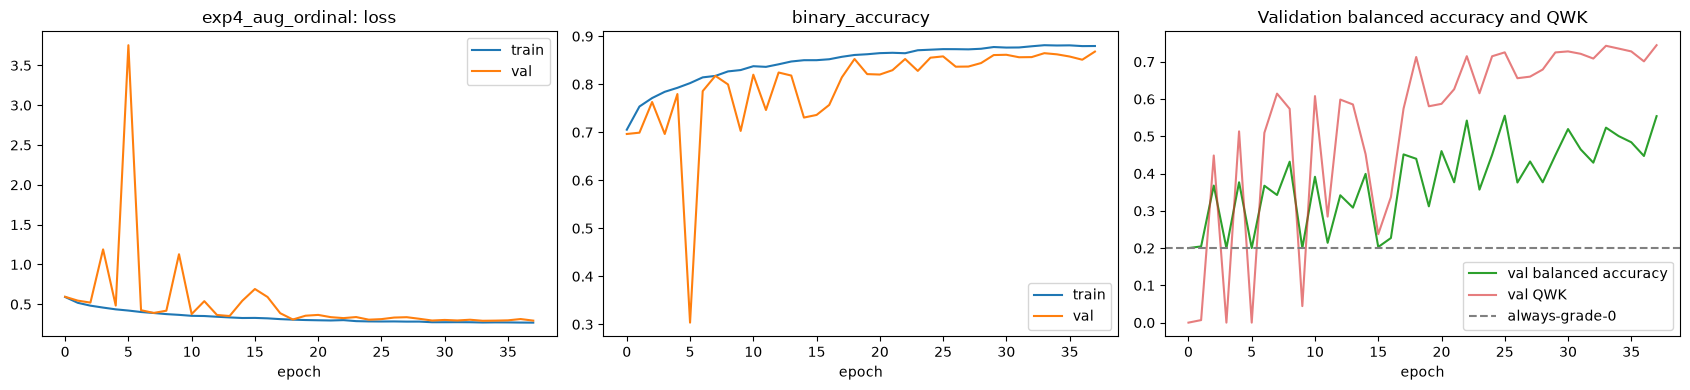

Balanced accuracy: 0.5553 | Accuracy: 0.5327 | QWK: 0.7253 | Macro F1: 0.5205

              precision    recall  f1-score   support

           0      0.718     0.567     0.634       328
           1      0.279     0.333     0.304       153
           2      0.509     0.646     0.570       212
           3      0.657     0.415     0.509       106
           4      0.458     0.815     0.587        27

    accuracy                          0.533       826
   macro avg      0.524     0.555     0.520       826
weighted avg      0.567     0.533     0.539       826



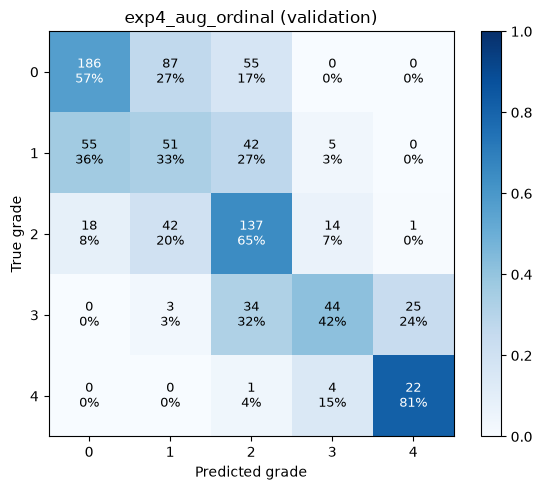

In [6]:
RUN = "exp4_aug_ordinal"
CONFIG = {"model": "ordinal_cnn", "head": "coral", "filters": [32, 64, 128, 256], "dropout": 0.3,
          "optimizer": "adam", "lr": 1e-3, "batch_size": 32, "class_weights": None,
          "augmentation": "flip+rot10+shift5+zoom10+bc10", "seed": 42}

ev.set_seed(42)
train_ds_ord = ordinal.to_ordinal(data.make_dataset(X_train, y_train, batch_size=32, shuffle=True,
                                                    augment=augment.build_augmentation()))
val_ds_ord = ordinal.to_ordinal(val_ds)
model = ordinal.build_ordinal_cnn()

best4, history4, m4 = train.train_and_evaluate(
    RUN, model, CONFIG, train_ds_ord, val_ds_ord, y_val,
    loss="binary_crossentropy", metrics=["binary_accuracy"],
    decode_fn=ordinal.decode_count, max_epochs=80)

In [7]:
p4 = ordinal.to_class_probs(best4.predict(val_ds, verbose=0))

variants = {"exp4 ordinal": p4,
            "ensemble(1,3)": (p1 + p3) / 2,
            "ensemble(1,3,4)": (p1 + p3 + p4) / 3}

for name, p in variants.items():
    for rule, pred in [("argmax", p.argmax(axis=1)), ("prior-adj", (p / prior).argmax(axis=1))]:
        m = ev.compute_metrics(y_val, pred)
        recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
        print(f"{name:18s} {rule:9s} bal_acc {m['balanced_accuracy']:.4f} | "
              f"qwk {m['qwk']:.4f} | recalls {recalls}")
    print()

exp4 ordinal       argmax    bal_acc 0.5080 | qwk 0.7005 | recalls 0.77 / 0.00 / 0.76 / 0.16 / 0.85
exp4 ordinal       prior-adj bal_acc 0.4381 | qwk 0.6264 | recalls 0.54 / 0.29 / 0.36 / 0.00 / 1.00

ensemble(1,3)      argmax    bal_acc 0.6300 | qwk 0.7256 | recalls 0.77 / 0.05 / 0.75 / 0.73 / 0.85
ensemble(1,3)      prior-adj bal_acc 0.6467 | qwk 0.7115 | recalls 0.43 / 0.51 / 0.65 / 0.72 / 0.93

ensemble(1,3,4)    argmax    bal_acc 0.6276 | qwk 0.7319 | recalls 0.79 / 0.01 / 0.78 / 0.66 / 0.89
ensemble(1,3,4)    prior-adj bal_acc 0.6048 | qwk 0.7185 | recalls 0.48 / 0.43 / 0.64 / 0.51 / 0.96



Raw arrays loaded and aligned: (5778, 224, 224) (826, 224, 224)
Epoch 1/80


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791133224.248358    3162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_56412__.94
I0000 00:00:1791133247.459381    3162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_56412__.94


  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 33s - 185ms/step - accuracy: 0.3583 - loss: 1.4609 - val_accuracy: 0.3971 - val_loss: 1.4423 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/80
  val_balanced_accuracy: 0.2160 | val_qwk: 0.0779
181/181 - 21s - 116ms/step - accuracy: 0.3740 - loss: 1.4326 - val_accuracy: 0.3620 - val_loss: 1.4403 - val_balanced_accuracy: 0.2160 - val_qwk: 0.0779 - learning_rate: 0.0010
Epoch 3/80
  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 21s - 116ms/step - accuracy: 0.3821 - loss: 1.4180 - val_accuracy: 0.3971 - val_loss: 1.4067 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/80
  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 - 21s - 116ms/step - accuracy: 0.3885 - loss: 1.4163 - val_accuracy: 0.3971 - val_loss: 1.4082 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/80
  val_balanced_accuracy: 0.2000 | va

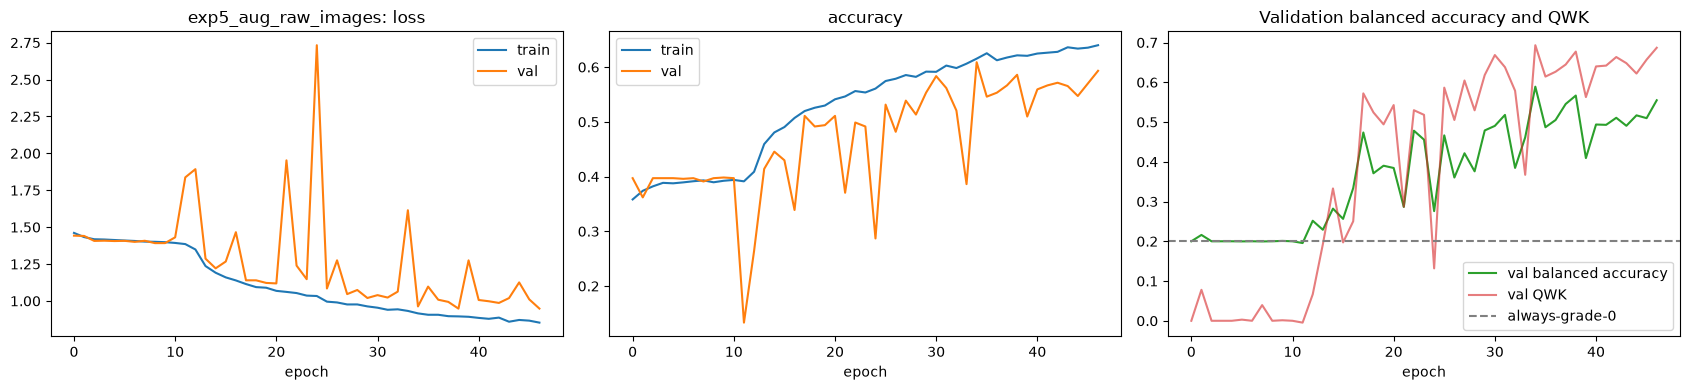

Balanced accuracy: 0.5890 | Accuracy: 0.6090 | QWK: 0.6933 | Macro F1: 0.5518

              precision    recall  f1-score   support

           0      0.609     0.863     0.714       328
           1      0.571     0.026     0.050       153
           2      0.561     0.561     0.561       212
           3      0.679     0.717     0.697       106
           4      0.700     0.778     0.737        27

    accuracy                          0.609       826
   macro avg      0.624     0.589     0.552       826
weighted avg      0.602     0.609     0.550       826



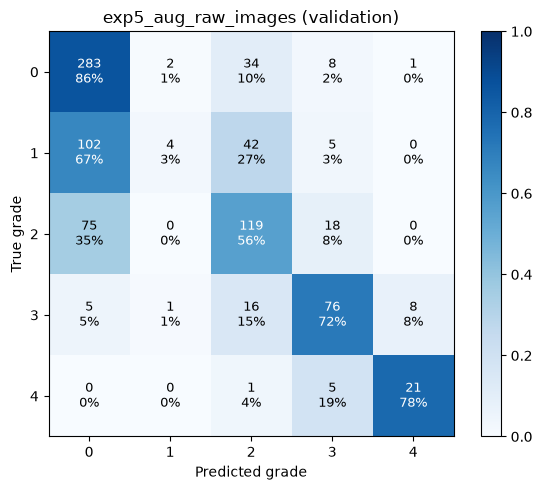

In [8]:
import cv2

meta = pd.read_csv(PROJECT / "data/processed/metadata.csv")

def load_raw(split):
    paths = meta.loc[meta.split == split, "path"]
    return np.stack([cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in paths])

X_train_raw, X_val_raw = load_raw("train"), load_raw("val")
assert (meta.loc[meta.split == "train", "grade"].to_numpy() == y_train).all()
assert (meta.loc[meta.split == "val", "grade"].to_numpy() == y_val).all()
print("Raw arrays loaded and aligned:", X_train_raw.shape, X_val_raw.shape)

RUN = "exp5_aug_raw_images"
CONFIG = {"model": "baseline_cnn", "filters": [32, 64, 128, 256], "dropout": 0.3,
          "optimizer": "adam", "lr": 1e-3, "batch_size": 32, "class_weights": None,
          "augmentation": "flip+rot10+shift5+zoom10+bc10", "preprocessing": "none (raw PNG)",
          "seed": 42}

ev.set_seed(42)
train_ds_raw = data.make_dataset(X_train_raw, y_train, batch_size=32, shuffle=True,
                                 augment=augment.build_augmentation())
val_ds_raw = data.make_dataset(X_val_raw, y_val, batch_size=64)
model = models.build_baseline_cnn()

best5, history5, m5 = train.train_and_evaluate(RUN, model, CONFIG, train_ds_raw, val_ds_raw, y_val,
                                               max_epochs=80)

In [9]:
p5 = best5.predict(val_ds_raw, verbose=0)
for name, p in [("exp1 preprocessed", p1), ("exp5 raw", p5)]:
    for rule, pred in [("argmax", p.argmax(axis=1)), ("prior-adj", (p / prior).argmax(axis=1))]:
        m = ev.compute_metrics(y_val, pred)
        recalls = " / ".join(f"{m[f'recall_g{g}']:.2f}" for g in range(5))
        print(f"{name:18s} {rule:9s} bal_acc {m['balanced_accuracy']:.4f} | "
              f"qwk {m['qwk']:.4f} | recalls {recalls}")
    print()

exp1 preprocessed  argmax    bal_acc 0.6131 | qwk 0.7206 | recalls 0.77 / 0.08 / 0.75 / 0.61 / 0.85
exp1 preprocessed  prior-adj bal_acc 0.6283 | qwk 0.6932 | recalls 0.33 / 0.61 / 0.59 / 0.69 / 0.93

exp5 raw           argmax    bal_acc 0.5890 | qwk 0.6933 | recalls 0.86 / 0.03 / 0.56 / 0.72 / 0.78
exp5 raw           prior-adj bal_acc 0.6098 | qwk 0.6959 | recalls 0.60 / 0.41 / 0.43 / 0.64 / 0.96

